# GTSRB: свёрточная сеть на TensorFlow

Классификация дорожных знаков. **43 класса**, ~39 000 картинок.

Сеть из **трёх свёрточных слоёв**. После каждого смотрим,
что сеть «видит» на этом уровне.

## 1. Импорты

In [1]:
%matplotlib inline
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(0)
tf.random.set_seed(0)

print('TensorFlow:', tf.__version__)
print('Keras     :', keras.__version__)

TensorFlow: 2.21.0
Keras     : 3.15.1


## 2. Загружаем данные

Датасет лежит в папке `data/`. Каждая подпапка `00000`, `00001`, ... — один класс.

In [2]:
DATA_DIR = Path('../../../data/gtsrb/GTSRB/Training')

paths, labels = [], []
for class_dir in sorted(DATA_DIR.iterdir()):
    if not class_dir.is_dir():
        continue
    for p in sorted(class_dir.glob('*.ppm')):
        paths.append(p)
        labels.append(int(class_dir.name))

labels = np.array(labels, dtype=np.int64)
print('картинок:', len(paths))
print('классов :', len(np.unique(labels)))

картинок: 26640
классов : 43


### Как выглядят знаки

⚠️ Картинки **разного размера** — приведём к одному.

размеры разных картинок: [(29, 30), (36, 37), (50, 48), (44, 50), (32, 39), (51, 50), (41, 41), (55, 54)]


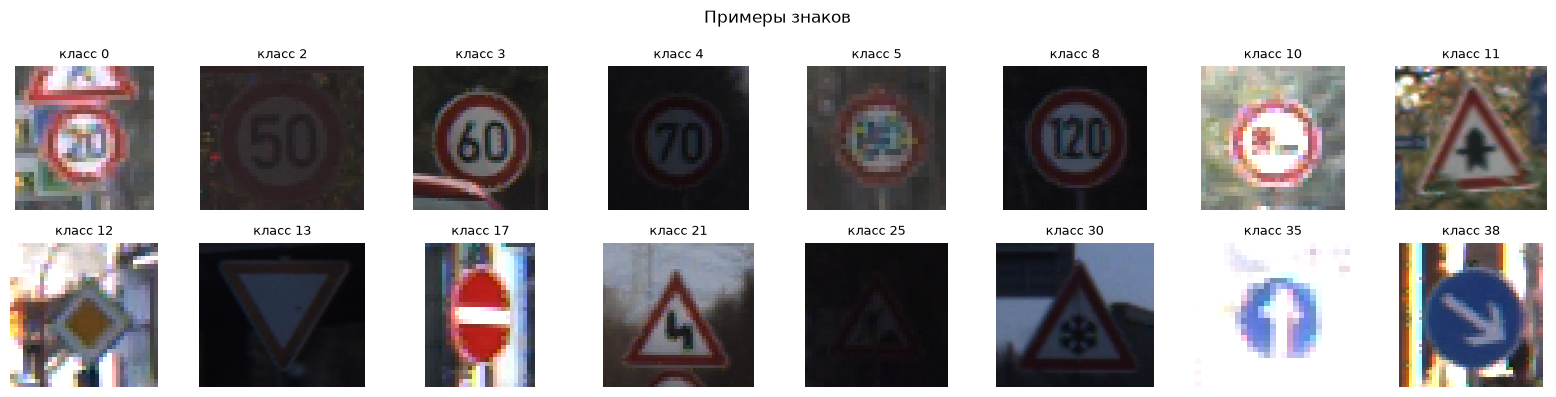

In [3]:
sizes = [Image.open(paths[i]).size for i in range(0, 2000, 250)]
print('размеры разных картинок:', sizes)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
step = len(paths) // 16
for ax, i in zip(axes.ravel(), range(0, len(paths), step)):
    ax.imshow(Image.open(paths[i]))
    ax.set_title('класс %d' % labels[i], fontsize=9)
    ax.axis('off')
plt.suptitle('Примеры знаков')
plt.tight_layout()
plt.show()

## 3. Готовим данные

- приводим к размеру **32x32**
- делим яркость на 255, чтобы числа были от 0 до 1
- делим на train и test: 80 / 20

In [4]:
IMG_SIZE = 32

t = time.time()
X = np.zeros((len(paths), IMG_SIZE, IMG_SIZE, 3), dtype=np.float32)
for i, p in enumerate(paths):
    X[i] = np.asarray(Image.open(p).resize((IMG_SIZE, IMG_SIZE)), dtype=np.float32) / 255.0
print('загружено за %.1f сек' % (time.time() - t))

idx = np.random.permutation(len(labels))
split = int(0.8 * len(idx))

X_train, y_train = X[idx[:split]], labels[idx[:split]]
X_test,  y_test  = X[idx[split:]], labels[idx[split:]]

print()
print('train:', X_train.shape)
print('test :', X_test.shape)

загружено за 4.1 сек

train: (21312, 32, 32, 3)
test : (5328, 32, 32, 3)


## 4. Свёрточная сеть

**Что делает свёртка (`Conv2D`):**
- берёт маленькое окно 3x3 и ездит им по картинке
- в каждом положении считает взвешенную сумму пикселей под окном
- **веса окна сеть подбирает сама** при обучении

**`MaxPooling2D`** уменьшает картинку вдвое, оставляя самое яркое в каждом
квадрате 2x2. Так сеть переходит от мелких деталей к крупным формам.

Три блока — три уровня детализации:

| слой | размер после | что примерно ищет |
|---|---|---|
| conv1 | 32x32 | границы, углы, пятна цвета |
| conv2 | 16x16 | простые формы из границ |
| conv3 | 8x8 | крупные части знака |

In [5]:
N_CLASSES = 43

model = keras.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    # свёрточный слой 1
    layers.Conv2D(32, 3, padding='same', activation='relu', name='conv1'),
    layers.MaxPooling2D(name='pool1'),                    # 32x32 -> 16x16

    # свёрточный слой 2
    layers.Conv2D(64, 3, padding='same', activation='relu', name='conv2'),
    layers.MaxPooling2D(name='pool2'),                    # 16x16 -> 8x8

    # свёрточный слой 3
    layers.Conv2D(128, 3, padding='same', activation='relu', name='conv3'),
    layers.MaxPooling2D(name='pool3'),                    # 8x8 -> 4x4

    # классификатор
    layers.Flatten(),
    layers.Dropout(0.4),
    layers.Dense(256, activation='relu'),
    layers.Dense(N_CLASSES),        # логиты, softmax внутри функции потерь
])

model.compile(
    optimizer='adam',
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy'],
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 628,843 (2.40 MB)

 Trainable params: 628,843 (2.40 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Обучаем

На процессоре это займёт несколько минут.

In [6]:
t = time.time()
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=128,
    verbose=2,
)
print()
print('обучение заняло: %.1f сек' % (time.time() - t))
print('ЛУЧШАЯ ТОЧНОСТЬ: %.4f  (%.2f%%)' % (max(history.history['val_accuracy']),
                                            max(history.history['val_accuracy']) * 100))

Epoch 1/10
167/167 - 7s - 42ms/step - accuracy: 0.3623 - loss: 2.3107 - val_accuracy: 0.6321 - val_loss: 1.1615
Epoch 2/10
167/167 - 8s - 47ms/step - accuracy: 0.7622 - loss: 0.7588 - val_accuracy: 0.8735 - val_loss: 0.4038
Epoch 3/10
167/167 - 8s - 50ms/step - accuracy: 0.8900 - loss: 0.3549 - val_accuracy: 0.9343 - val_loss: 0.2216
Epoch 4/10
167/167 - 9s - 56ms/step - accuracy: 0.9334 - loss: 0.2155 - val_accuracy: 0.9632 - val_loss: 0.1245
Epoch 5/10
167/167 - 8s - 47ms/step - accuracy: 0.9553 - loss: 0.1454 - val_accuracy: 0.9803 - val_loss: 0.0753
Epoch 6/10
167/167 - 7s - 44ms/step - accuracy: 0.9686 - loss: 0.1045 - val_accuracy: 0.9807 - val_loss: 0.0756
Epoch 7/10
167/167 - 10s - 61ms/step - accuracy: 0.9747 - loss: 0.0830 - val_accuracy: 0.9842 - val_loss: 0.0591
Epoch 8/10
167/167 - 27s - 163ms/step - accuracy: 0.9782 - loss: 0.0699 - val_accuracy: 0.9889 - val_loss: 0.0448
Epoch 9/10
167/167 - 60s - 357ms/step - accuracy: 0.9832 - loss: 0.0526 - val_accuracy: 0.9910 - val_

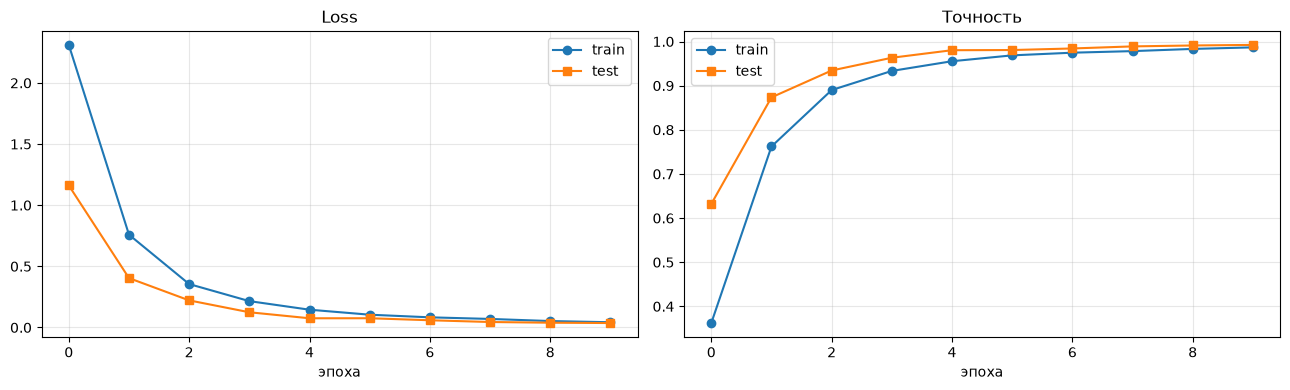

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].plot(history.history['loss'], marker='o', label='train')
ax[0].plot(history.history['val_loss'], marker='s', label='test')
ax[0].set_title('Loss')
ax[0].set_xlabel('эпоха')
ax[0].legend()
ax[0].grid(alpha=0.3)

ax[1].plot(history.history['accuracy'], marker='o', label='train')
ax[1].plot(history.history['val_accuracy'], marker='s', label='test')
ax[1].set_title('Точность')
ax[1].set_xlabel('эпоха')
ax[1].legend()
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Что сеть видит после каждого слоя

Берём одну картинку и смотрим, во что она превращается после каждой свёртки.

Каждый свёрточный слой выдаёт **много картинок сразу** — по одной на фильтр.
Это называется **карты признаков** (feature maps).

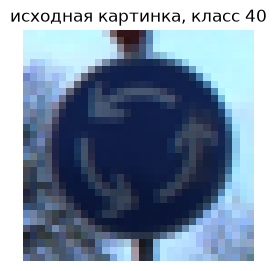

In [8]:
# Берём одну картинку для разбора. Поменяй индекс, чтобы посмотреть другой знак.
SAMPLE = 100

sample = X_test[SAMPLE:SAMPLE + 1]        # форма (1, 32, 32, 3) - модель ждёт "пачку"

plt.figure(figsize=(3, 3))
plt.imshow(sample[0])
plt.title('исходная картинка, класс %d' % y_test[SAMPLE])
plt.axis('off')
plt.show()

### Достаём карты признаков

Создаём вспомогательную модель, которая возвращает выход нужного слоя.

In [9]:
def feature_maps(layer_name, image):
    """Возвращает карты признаков после указанного слоя."""
    sub_model = keras.Model(inputs=model.inputs,
                            outputs=model.get_layer(layer_name).output)
    return sub_model.predict(image, verbose=0)[0]      # (высота, ширина, фильтры)


for name in ['conv1', 'conv2', 'conv3']:
    fm = feature_maps(name, sample)
    print('%s -> %d карт размером %dx%d' % (name, fm.shape[2], fm.shape[0], fm.shape[1]))

conv1 -> 32 карт размером 32x32
conv2 -> 64 карт размером 16x16
conv3 -> 128 карт размером 8x8


### Слой 1: границы и пятна

Картинка ещё 32x32 — видно очертания знака.
Разные фильтры реагируют на разное: один на светлое, другой на края, третий на цвет.

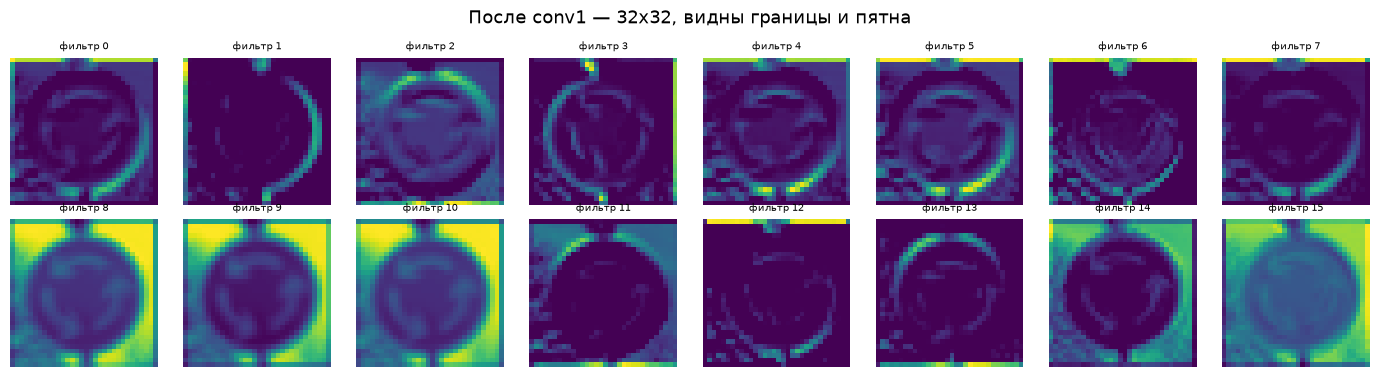

In [10]:
def show_maps(layer_name, image, n=16, title=''):
    fm = feature_maps(layer_name, image)
    rows = int(np.ceil(n / 8))
    fig, axes = plt.subplots(rows, 8, figsize=(14, 1.9 * rows))
    for ax, i in zip(np.array(axes).ravel(), range(n)):
        ax.imshow(fm[:, :, i], cmap='viridis')
        ax.set_title('фильтр %d' % i, fontsize=7)
        ax.axis('off')
    plt.suptitle(title or layer_name, fontsize=13)
    plt.tight_layout()
    plt.show()


show_maps('conv1', sample, n=16,
          title='После conv1 — 32x32, видны границы и пятна')

### Слой 2: простые формы

Картинка уменьшилась до 16x16. Детали пропали, но проступают более крупные структуры.

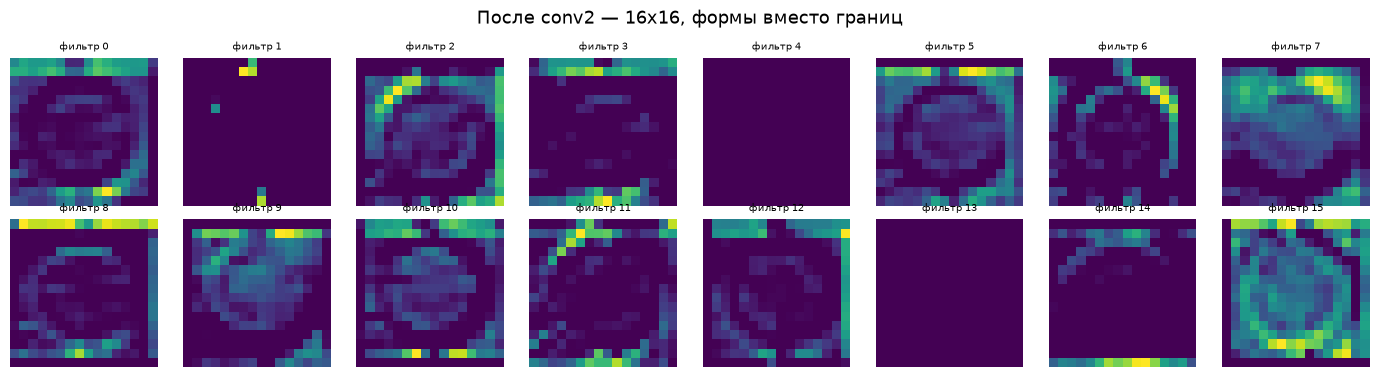

In [11]:
show_maps('conv2', sample, n=16,
          title='После conv2 — 16x16, формы вместо границ')

### Слой 3: абстракция

8x8 — узнать знак глазами уже почти невозможно.
Это **нормально**: сеть здесь хранит не картинку, а признаки вроде
«есть красное кольцо», «внутри тёмная фигура».

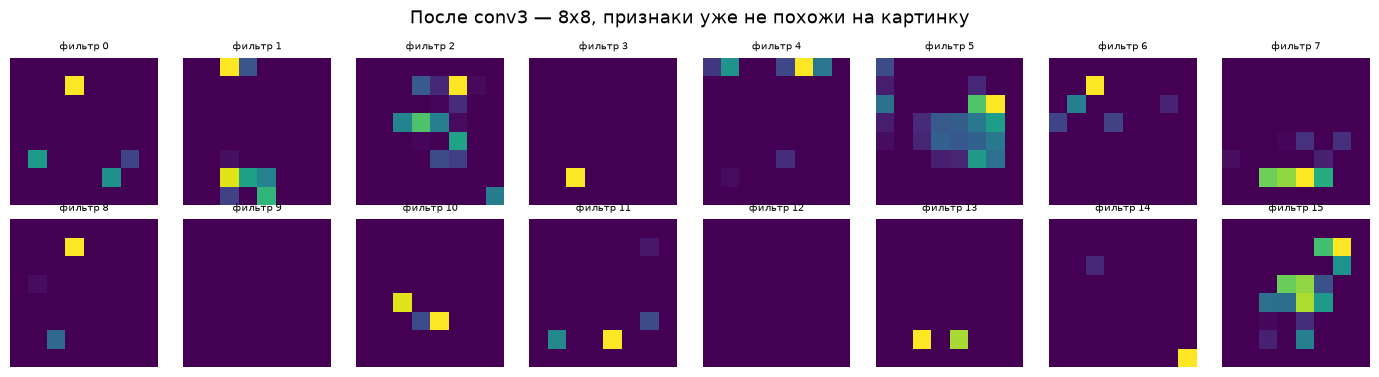

In [12]:
show_maps('conv3', sample, n=16,
          title='После conv3 — 8x8, признаки уже не похожи на картинку')

### Всё вместе: как «сжимается» картинка

Один и тот же фильтр на трёх уровнях — видно, как теряются детали
и растёт абстракция.

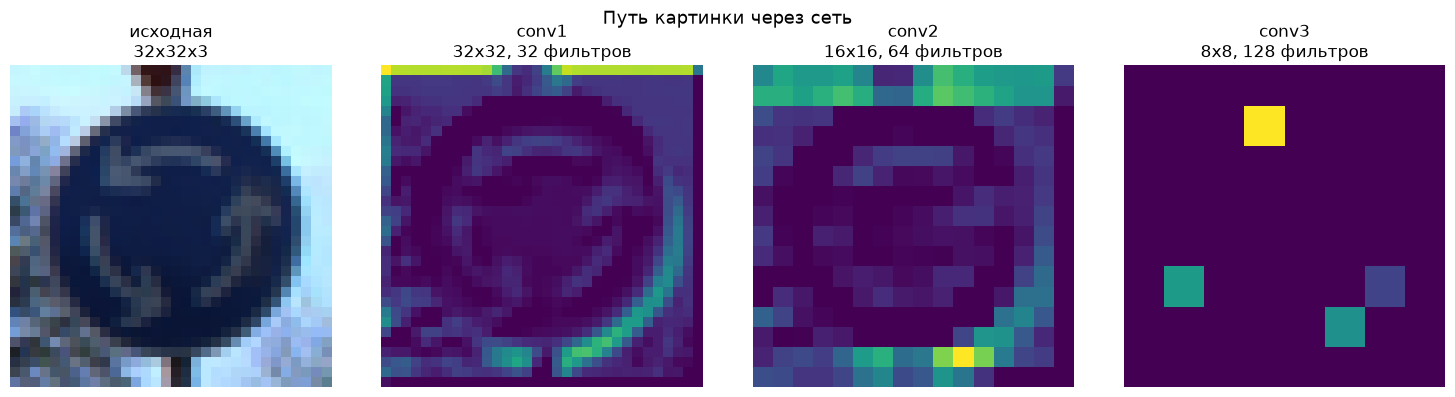

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

axes[0].imshow(sample[0])
axes[0].set_title('исходная\n32x32x3')
axes[0].axis('off')

for ax, name in zip(axes[1:], ['conv1', 'conv2', 'conv3']):
    fm = feature_maps(name, sample)
    ax.imshow(fm[:, :, 0], cmap='viridis')
    ax.set_title('%s\n%dx%d, %d фильтров' % (name, fm.shape[0], fm.shape[1], fm.shape[2]))
    ax.axis('off')

plt.suptitle('Путь картинки через сеть', fontsize=13)
plt.tight_layout()
plt.show()

### Что выучил первый слой

Веса `conv1` — те самые окна 3x3, которые сеть подобрала сама.
Их можно показать как маленькие цветные картинки.

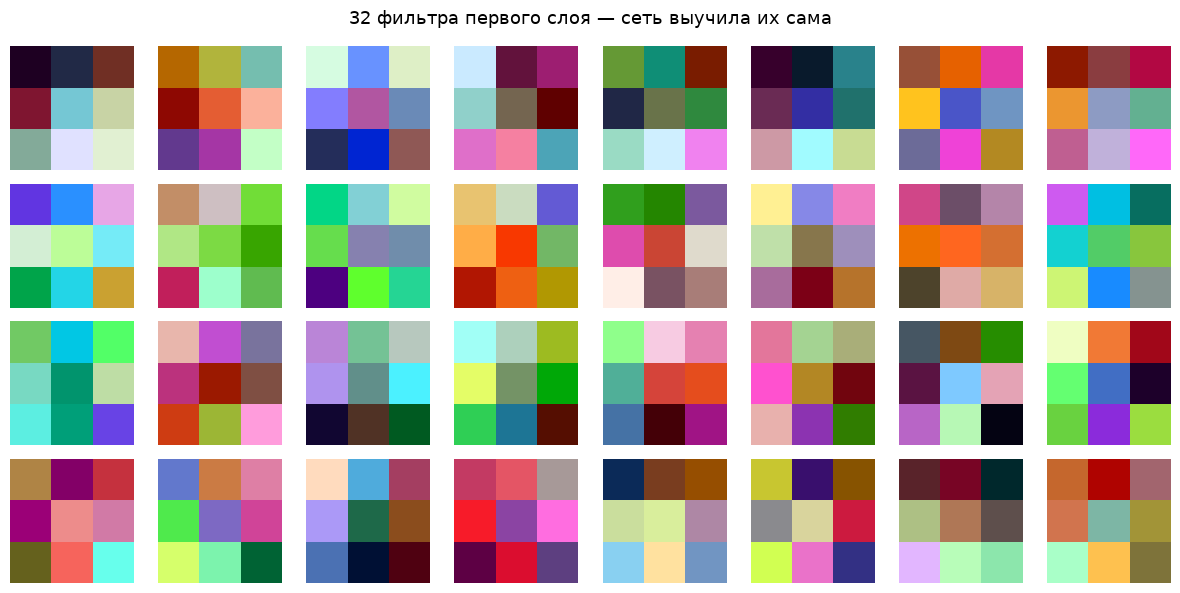

In [14]:
w = model.get_layer('conv1').get_weights()[0]     # (3, 3, 3, 32)

fig, axes = plt.subplots(4, 8, figsize=(12, 6))
for ax, i in zip(axes.ravel(), range(32)):
    f = w[:, :, :, i]
    f = (f - f.min()) / (f.max() - f.min() + 1e-8)    # нормируем для показа
    ax.imshow(f)
    ax.axis('off')
plt.suptitle('32 фильтра первого слоя — сеть выучила их сама', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Проверяем предсказания

точность на тесте: 0.9923  (99.23%)


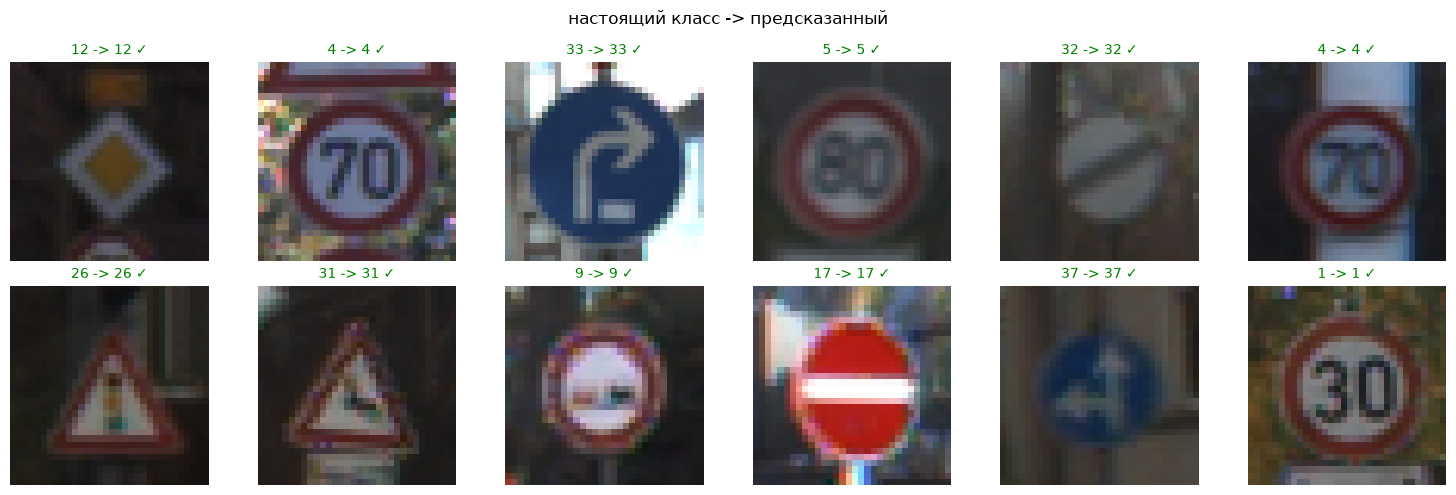

In [15]:
pred = model.predict(X_test, verbose=0)
pred_class = pred.argmax(axis=1)

acc = (pred_class == y_test).mean()
print('точность на тесте: %.4f  (%.2f%%)' % (acc, acc * 100))

# Показываем несколько примеров
fig, axes = plt.subplots(2, 6, figsize=(15, 5))
for ax, i in zip(axes.ravel(), np.random.choice(len(X_test), 12, replace=False)):
    ax.imshow(X_test[i])
    ok = pred_class[i] == y_test[i]
    ax.set_title('%d -> %d %s' % (y_test[i], pred_class[i], '✓' if ok else '✗'),
                 fontsize=10, color='green' if ok else 'red')
    ax.axis('off')
plt.suptitle('настоящий класс -> предсказанный')
plt.tight_layout()
plt.show()

## Выводы

**Свёрточная сеть работает с картинкой как с двумерной** — в отличие от
полносвязной, которая вытягивает её в строку и теряет соседство пикселей.

**Что происходит по слоям:**

| слой | размер | что хранит |
|---|---|---|
| вход | 32x32x3 | сама картинка |
| conv1 | 32x32x32 | границы, углы, пятна цвета |
| conv2 | 16x16x64 | простые формы |
| conv3 | 8x8x128 | абстрактные признаки |

**Важно:** на третьем слое картинку глазами уже не узнать — и это правильно.
Сеть хранит там не изображение, а ответы на вопросы вроде «есть ли красное
кольцо» и «какая фигура внутри». Именно по ним и делается вывод о классе знака.

**Ключевая мысль:** фильтры никто не задавал вручную — сеть подобрала их сама
по данным. В классических методах (HOG, признаки Хаара) их придумывал человек.